<a href="https://colab.research.google.com/github/pedrobiqua/estatistica/blob/main/Estat%C3%ADstica_Mestrado_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estatistica

Base de dados utilizado: https://dados.gov.br/dados/conjuntos-dados/crimes-violentos

In [ ]:
# !wget https://dados.mg.gov.br/dataset/87e4675b-bb0a-444a-ba0f-1463b893d01a/resource/bd02f7db-04cc-4149-98ee-e6fb2e713b04/download/crimes_violentos_2024.csv

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('crimes_violentos_2024.csv', sep=';')

In [ ]:
df

,registros,natureza,municipio,cod_municipio,mes,ano,risp,rmbh
0,0,Estupro Consumado,ABADIA DOS DOURADOS,310010,1,2024,10,NÃO
1,0,Estupro Consumado,ABAETE,310020,1,2024,7,NÃO
2,0,Estupro Consumado,ABRE-CAMPO,310030,1,2024,12,NÃO
3,0,Estupro Consumado,ACAIACA,310040,1,2024,12,NÃO
4,1,Estupro Consumado,ACUCENA,310050,1,2024,12,NÃO
...,...,...,...,...,...,...,...,...
133063,0,Homicídio Consumado (Registros),VIRGOLANDIA,317190,12,2024,8,NÃO
133064,0,Homicídio Consumado (Registros),VISCONDE DO RIO BRANCO,317200,12,2024,4,NÃO
133065,0,Homicídio Consumado (Registros),VOLTA GRANDE,317210,12,2024,4,NÃO
133066,0,Homicídio Consumado (Registros),WENCESLAU BRAZ,317220,12,2024,17,NÃO


Obs: Para o exercicio 1 eu restringi a minha análise para o municipio de Belo Horizonte com crimes de Homicídio Consumado (Registros) para eu poder replicar no caderno para exercitar fazendo as contas e passos no caderno.

In [ ]:
# Exercicio 1: Tabela de distribuição de frequencia

# Base de dados
df_bh = df[df['municipio'].str.upper() == 'BELO HORIZONTE']
df_bh_homicidio = df_bh[df_bh['natureza'] == 'Homicídio Consumado (Registros)']

df_dados = df_bh_homicidio['registros']
df_dados.sort_values()

,registros
123684,17
124537,26
129655,26
130508,26
126243,27
125390,28
131361,28
127949,28
132214,29
128802,30


In [ ]:
# Deixar em rol/ordenar
df_dados_rol = df_dados.sort_values()
menor_valor = df_dados_rol.iloc[0]
maior_valor = df_dados_rol.iloc[-1]

# Obter a amplitude total
amplitude_total = maior_valor - menor_valor

# Quantidade de classes (Sturges)
k = int(1 + 3.322 * np.log10(len(df_dados_rol)))

# Amplitude de cada classe
h = amplitude_total / k

print(f'amplitude total={amplitude_total} k={k} h={h}')

# Passo 1: criar os limites das classes
limites_classes = [menor_valor + i * h for i in range(k + 1)]

# Passo 2: calcular frequências
frequencias, _ = np.histogram(df_dados_rol, bins=limites_classes)

# Passo 3: calcular ponto médio de cada classe
classes = []
pontos_medios = []
for i in range(k):
    inferior = limites_classes[i]
    superior = limites_classes[i + 1]
    classes.append(f"{inferior:.2f} ⊢ {superior:.2f}")
    pontos_medios.append((inferior + superior) / 2)

# Frequência acumulada
frequencia_acumulada = np.cumsum(frequencias)

# Criar o DataFrame com a tabela
tabela_frequencia = pd.DataFrame({
    'Classe': classes,
    'Frequência (fi)': frequencias,
    'Pontos Médios (xi)': pontos_medios,
    'Frequência Acumulada (Fi)': frequencia_acumulada
})

# Exibir a tabela
print("\n Tabela de Distribuição de Frequência\n")
print(tabela_frequencia)

# Somatório de fi
print(f"\nSomatório de fi: {tabela_frequencia['Frequência (fi)'].sum()}")

amplitude total=17 k=4 h=4.25

 Tabela de Distribuição de Frequência

          Classe  Frequência (fi)  Pontos Médios (xi)  \
0  17.00 ⊢ 21.25                1              19.125   
1  21.25 ⊢ 25.50                0              23.375   
2  25.50 ⊢ 29.75                8              27.625   
3  29.75 ⊢ 34.00                3              31.875   

   Frequência Acumulada (Fi)  
0                          1  
1                          1  
2                          9  
3                         12  

Somatório de fi: 12


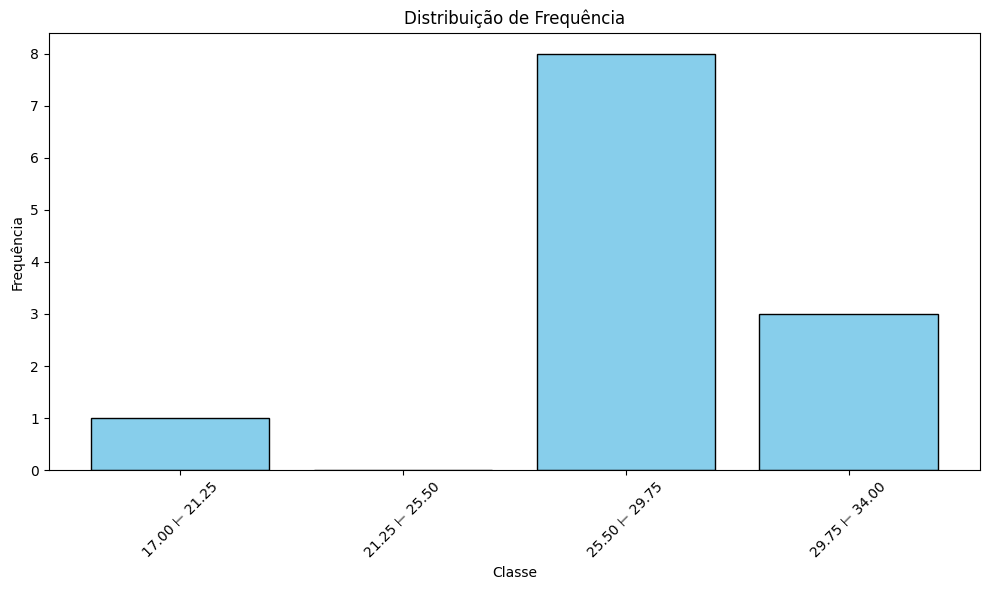

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(tabela_frequencia["Classe"], tabela_frequencia["Frequência (fi)"], color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel("Classe")
plt.ylabel("Frequência")
plt.title("Distribuição de Frequência")
plt.tight_layout()
plt.show()
